# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df =pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfacción`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna edad debería ser de tipo entera.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int')

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


Diagnóstico inicial de variables numéricas

- `edad`: Rango de 18 - 75 años, distribución relativamente normal (media ≈ mediana).
- `nivel_ingreso`: Rango de 8000 - 75000, distribución relativamente normal ((media ≈ mediana).
- `visitas_mes`: Rango de 1 - 25, en promedio los usuarios visitan la plataforma 10 veces al mes.
- `compras_mes`: Rango de 0 - 8, el 25% de los usuarios no compran nada al mes.
- `gasto_publicidad_dirigida`: Rango de 0 - 76, distribución no es normal (media ≠ mediana).
- `satisfaccion`: Rango de 1 - 5, en promedio los usuarios tienen una satisfacción de 3,6.
- `ingreso_anual`: Rango de 0 - 245, alta variabilidad, el 25% de los usuarios no tienen un ingreso anual.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles


In [ ]:
df['miembro_premium'].value_counts()

0    12911
1     2089
Name: miembro_premium, dtype: int64

In [ ]:
df['abandono'].value_counts()

0    12739
1     2261
Name: abandono, dtype: int64


Diagnóstico inicial de variables binarias

- `miembro_premium` — Solo tiene valores 0 y 1, sin valores faltantes el 75% de los datos es 0, es decir, no son miembros premium.
- `abandono` — Solo tiene valores 0 y 1, sin valores faltantes el 75% de los datos es 0, es decir, no abandona.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']

for columna in columnas_categoricas:
    print(f"\n{columna}:")
    print(f"  Valores únicos: {df[columna].nunique()}")


id_cliente:
  Valores únicos: 15000

tipo_dispositivo:
  Valores únicos: 3

region:
  Valores únicos: 4


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
df[['id_cliente', 'tipo_dispositivo', 'region']].describe()

,id_cliente,tipo_dispositivo,region
count,15000,15000,15000
unique,15000,3,4
top,CL-105536,móvil,norte
freq,1,9818,4395


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` : existen tres tipos de categorías, móvil es la categoría más utilizada con una freccuencia de 9818.
- `id_cliente`: 15000 valores únicos, cada cliente tiene su propio ID.
- `region`: existen 4 tipos de categorías, siendo la región norte la de mayor frecuencia con un valor de 4395.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

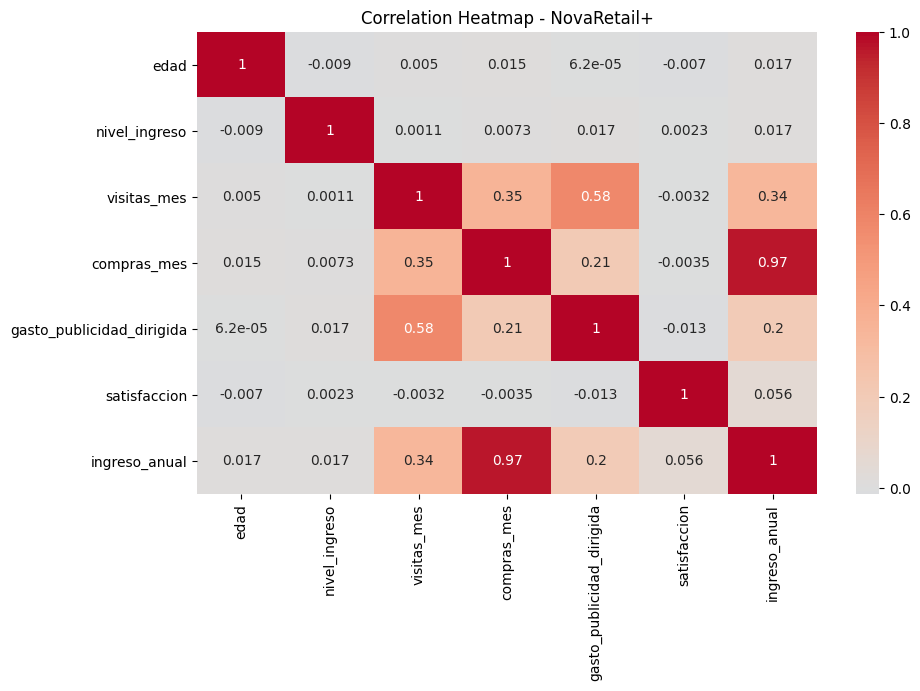

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot= True, cmap= "coolwarm", center = 0)
plt.title ("Correlation Heatmap - NovaRetail+")
plt.show()

Observaciones generales (Heatmap)  
- Se observa una fuerte correlación positiva entre compras_mes y ingreso_anual (0.97), lo que indica que a mayor número de compras, mayor ingreso generado por el cliente.
Existe una correlación moderada entre visitas_mes y gasto_publicidad_dirigida (0.58), lo que sugiere que la publicidad está impulsando el tráfico hacia la plataforma.
La relación entre visitas_mes y compras_mes (0.35) es positiva pero moderada, lo que evidencia oportunidades de mejora en la conversión.
La mayoría de variables como edad, nivel de ingreso y satisfacción muestran correlaciones cercanas a cero, indicando que tienen poca relación lineal directa con el comportamiento de compra.

Observaciones respecto a `ingreso_anual`  
- Presenta una correlación extremadamente alta con compras_mes (0.97). Esto sugiere que el ingreso anual depende casi directamente del volumen de compras (posible variable derivada).
Tiene una correlación moderada con visitas_mes (0.34). Más visitas tienden a generar más ingresos, pero no de forma tan fuerte como las compras.
Muestra una correlación baja con gasto_publicidad_dirigida (0.20). La publicidad impacta, pero de forma indirecta (primero aumenta visitas/compras).
La relación con satisfaccion (0.056) es prácticamente nula. La satisfacción no está influyendo directamente en el ingreso en este dataset.


### Scatterplot general

1. Relación entre visitas_mes, compras_mes e ingreso_anual
Se observa una relación positiva clara entre visitas_mes y compras_mes. A mayor número de visitas, mayor número de compras
La relación entre compras_mes e ingreso_anual es casi lineal. Confirma lo visto en el heatmap: el ingreso depende directamente de las compras
También hay relación positiva entre: visitas_mes → ingreso_anual (pero más dispersa)
2. Impacto de gasto_publicidad_dirigida. Se observa una tendencia positiva con visitas_mes. La publicidad está generando tráfico
Relación más débil con compras_mes. La publicidad atrae usuarios, pero no garantiza conversión.
3. satisfaccion: No muestra patrones claros con: compras, visitas ni ingreso.
4. Variables demográficas (edad, nivel_ingreso)
Distribuciones bastante uniformes, sin patrones claros con: compras, visitas e ingreso.

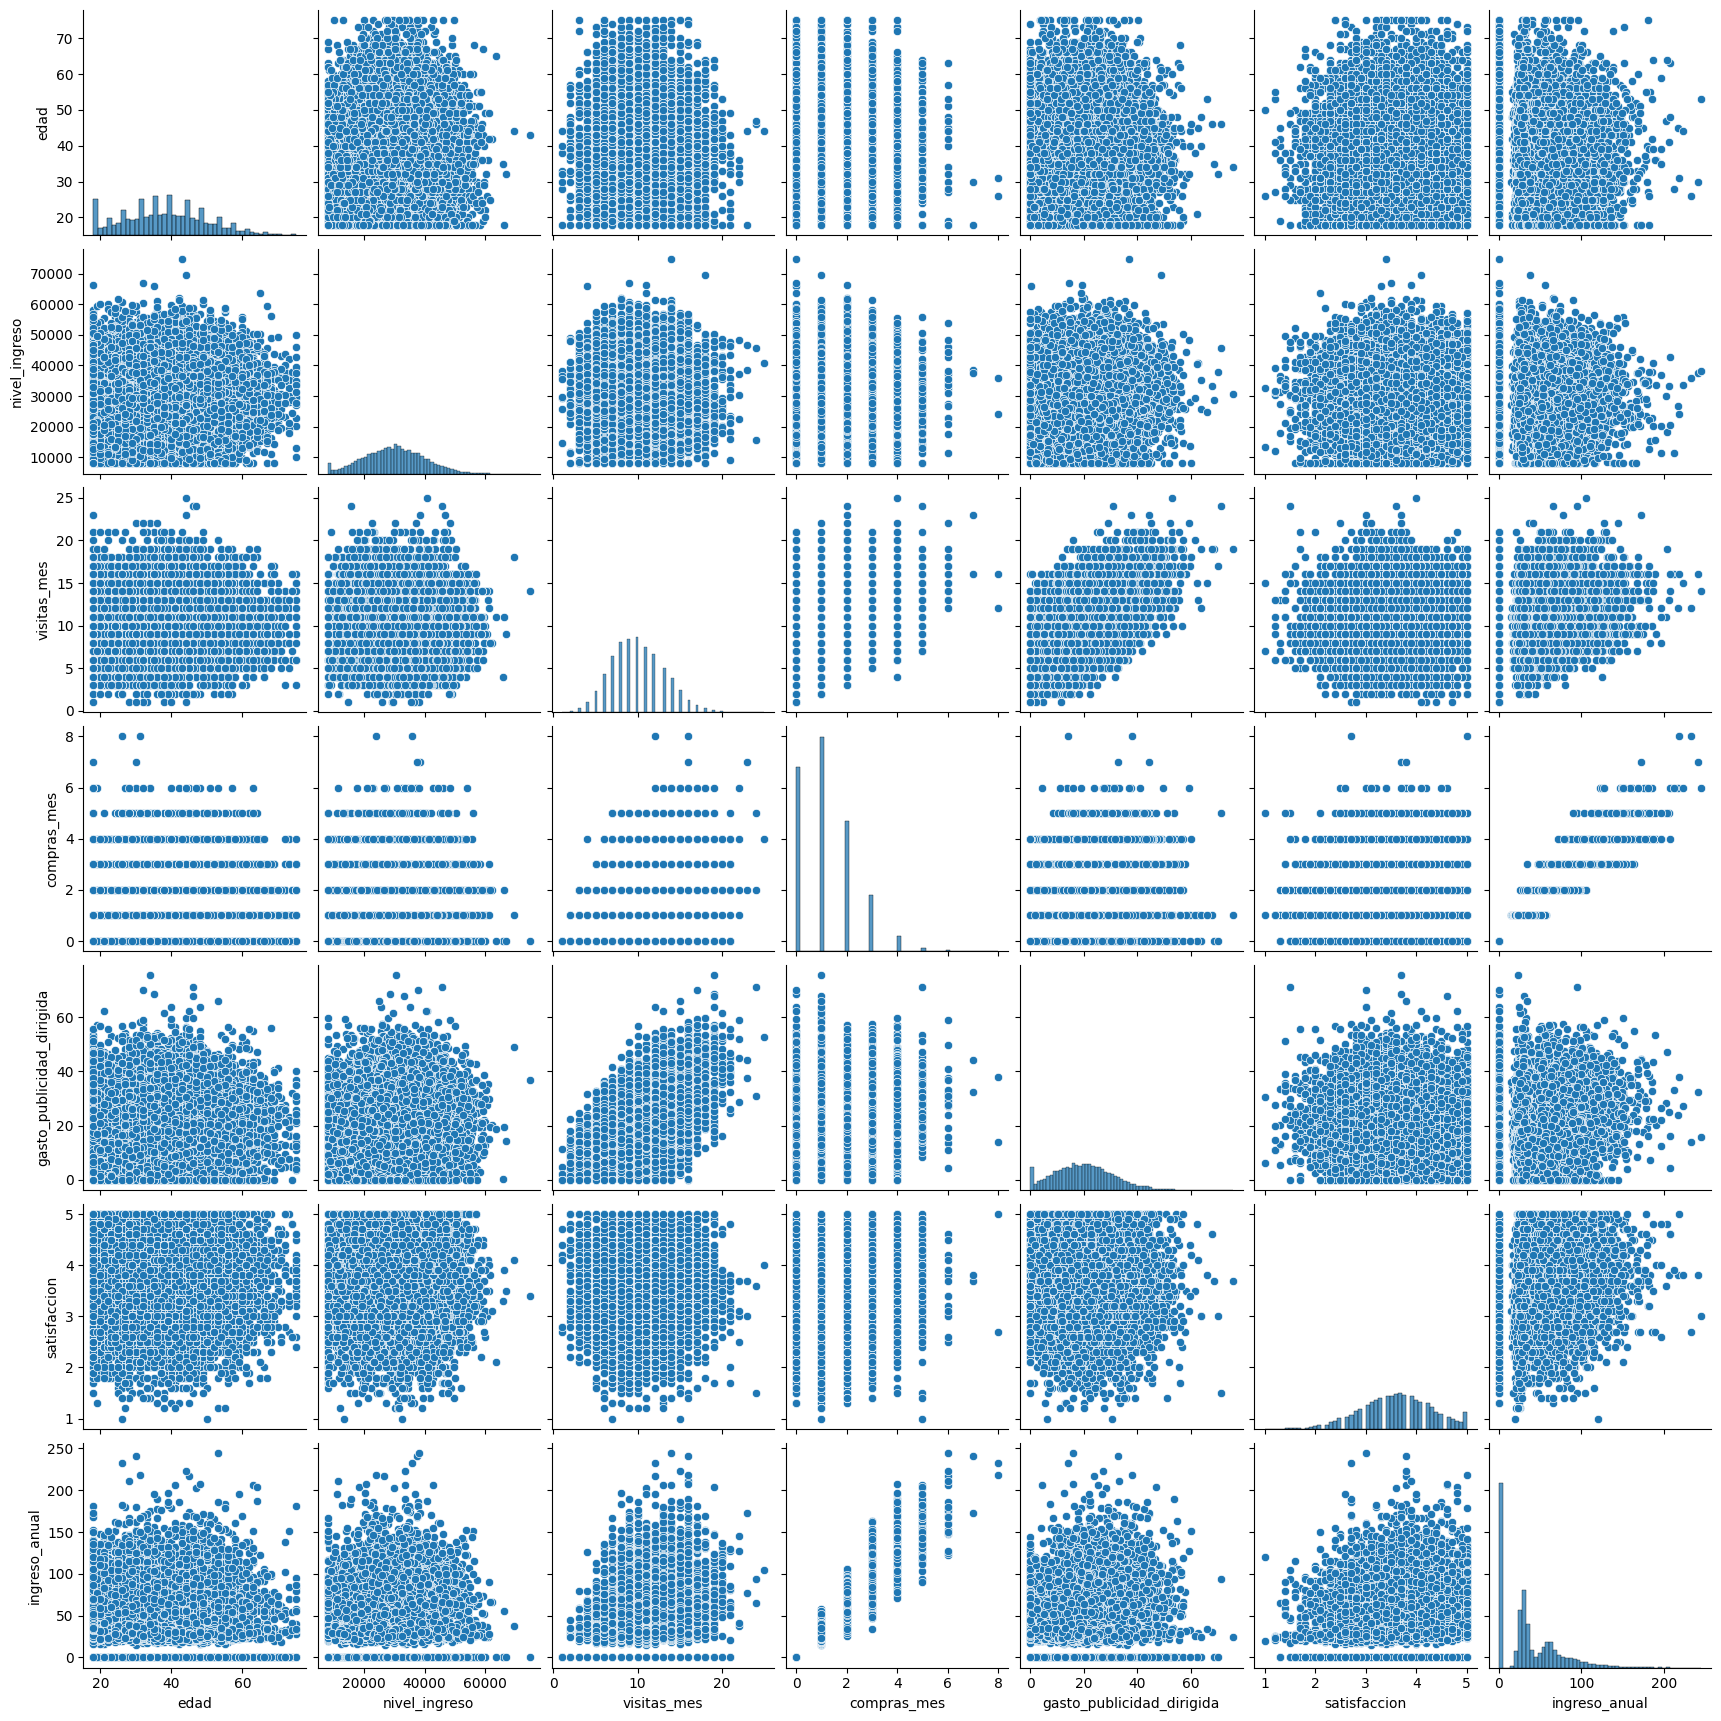

In [ ]:
sns.pairplot(df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']])

### Scatterplot para pares clave

<AxesSubplot:xlabel='ingreso_anual', ylabel='compras_mes'>

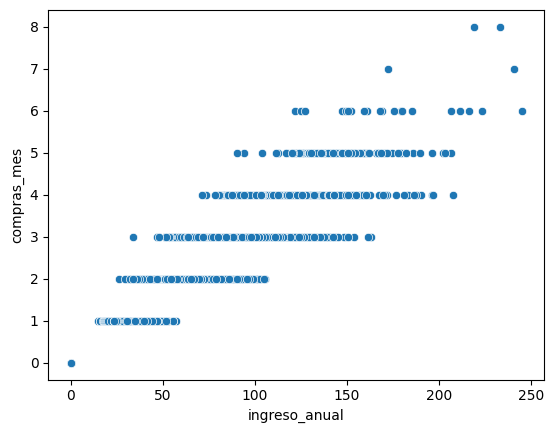

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x='ingreso_anual', y= 'compras_mes')

<AxesSubplot:xlabel='ingreso_anual', ylabel='visitas_mes'>

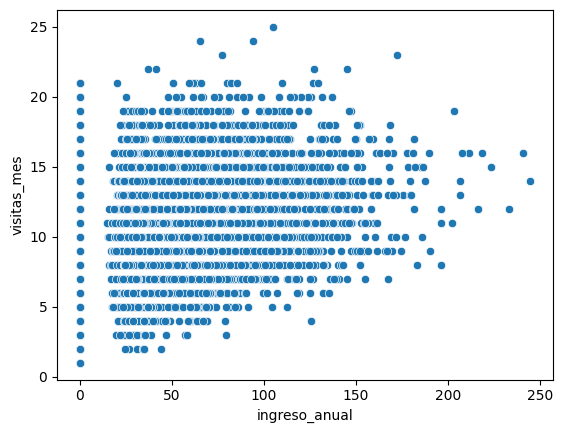

In [ ]:
sns.scatterplot(data=df, x='ingreso_anual', y='visitas_mes')

Observaciones iniciales (Scatterplot)

**compra_mes vs ingreso anual**
- Dirección positiva
- relación fuerte
- dispersión media
- presencia de outliers
- posible colinealidad

**ingreso_anual vs visitas_mes**
- Dirección positiva
- relación baja
- dispersión alta
- presencia de outliers
- no hay colinealidad

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
df['compras_mes'].corr(df['ingreso_anual'], method= 'pearson')

0.9671485435708564

In [ ]:
df['compras_mes'].corr(df['ingreso_anual'], method= 'spearman')

0.967482492032673

In [ ]:

7# Calcular correlación entre variables relevantes
df['visitas_mes'].corr(df['ingreso_anual'],method= 'pearson')


0.3371466432498745

In [ ]:
df['visitas_mes'].corr(df['ingreso_anual'],method= 'spearman')

0.32095369737696483

Observaciones de correlación

**compras_mes vs ingreso_anual**
- Correlación fuerte positiva y consistente, con posible colinealidad (Pearson = 0.97; Spearman = 0.97).
- La relación es lineal y monotónica.
- ingreso_anual está prácticamente explicado por compras_mes. Es muy probable que sea una variable derivada

**visitas_mes vs ingreso_anual**
- Se encontró una correlación positiva débil (Pearson = 0.34; Spearman = 0.32), indicando una relación limitada entre las variables.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes

from scipy.stats import pointbiserialr
pointbiserialr(df["miembro_premium"],df["ingreso_anual"])


SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

In [ ]:
# Calcular correlación entre variables relevantes
pointbiserialr(df["abandono"],df["ingreso_anual"])

SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
tabla = pd.crosstab(
    df["region"],
    df["tipo_dispositivo"]
)
tabla

tipo_dispositivo,escritorio,móvil,tablet
region,,,
este,766,2003,300
norte,1125,2843,427
oeste,935,2489,386
sur,894,2483,349


In [ ]:
# Aplicar V de Cramér en variables relevantes

chi2, p, dof, expected  = chi2_contingency(tabla)
chi2

4.596697852095489

In [ ]:

n = tabla.values.sum()
v = np.sqrt(chi2/(n*(min(tabla.shape)-1)))
v


0.012378338407739397

Observaciones V de Cramér

relación muy débil,
prácticamente no hay relación.
El tipo de dispositivo que usa un usuario no es relevante en cada región.

In [ ]:
# Función para calcular V de Cramér
tabla = pd.crosstab(
    df["region"],
    df["abandono"]
)
tabla

In [ ]:
# Aplicar V de Cramér en variables relevantes

chi2, p, dof, expected  = chi2_contingency(tabla)
chi2

In [ ]:
n = tabla.values.sum()
v = np.sqrt(chi2/(n*(min(tabla.shape)-1)))
v

0.012378338407739397




Observaciones V de Cramér
- relación muy débil, prácticamente no hay relación.
- No existe relación significativa entre la región y el abandono
- La región no influye no influye en la probabilidad de churn



In [ ]:
# Función para calcular V de Cramér
tabla = pd.crosstab(
    df["tipo_dispositivo"],
    df["abandono"]
)
tabla

In [ ]:
# Aplicar V de Cramér en variables relevantes

chi2, p, dof, expected  = chi2_contingency(tabla)
chi2

In [ ]:

n = tabla.values.sum()
v = np.sqrt(chi2/(n*(min(tabla.shape)-1)))
v


0.012378338407739397


Observaciones V de Cramér
- relación muy débil, prácticamente no hay relación.
- No existe relación significativa entre el tipo de dispositivo y el abandono
- El dispositivo utilizado no influye en la probabilidad de churn


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — El ingreso está altamente impulsado por la frecuencia de compra

**Evidencia visual:**
- Heatmap de correlación → muestra alta relación entre compras_mes e ingreso_anual
- Scatterplot (compras_mes vs ingreso_anual) → tendencia lineal positiva clara
  
**Evidencia numérica:** Correlación de Pearson: 0.967

**Interpretación**  
Existe una relación positiva muy fuerte entre el número de compras mensuales y el ingreso anual, lo que indica que los clientes que compran con mayor frecuencia tienden a generar mayores ingresos.

**No podemos afirmar**  
- Que aumentar las compras necesariamente cause un incremento directo en el ingreso.
- Que esta relación no esté influenciada por otras variables.
- Que el ingreso no sea una variable derivada de las compras.

**Implicación de negocio**  
- Estrategias enfocadas en incrementar la frecuencia de compra (fidelización, recompra, suscripciones) pueden tener un impacto significativo en los ingresos.
- Es clave complementar este análisis con métricas como ticket promedio para identificar oportunidades adicionales de crecimiento.
- Se recomienda evitar usar ambas variables juntas debido a su alta colinealidad.

### Hallazgo 2 — Relación entre ingreso_anual y visitas_mes

**Evidencia visual:**  
- Heatmap de correlación → relación baja entre ingreso_anual y visitas_mes
- Pairplot → tendencia positiva entre ambas variables, con dispersión visible
**Evidencia numérica:** Coeficiente de Pearson: 0.337
                        Coeficiente de Spearman: 0.321

**Interpretación**  
Existe una relación positiva débil entre el ingreso anual y las visitas mensuales:

Los clientes con mayores ingresos tienden a visitar ligeramente más. Sin embargo, el ingreso no es un factor determinante del comportamiento

**No podemos afirmar**  

- Que el ingreso cause un aumento en las visitas
- Que aumentar el ingreso de un cliente incrementará su frecuencia de uso
- Que esta variable sea suficiente para predecir el comportamiento de visitas

**Implicación de negocio**  
- El ingreso puede ser útil para una segmentación básica, pero no debe ser la única variable
- Las visitas parecen depender más de: engagement, experiencia del usuario y frecuencia de uso del servicio
-Diseñar estrategias enfocadas en retención y engagement, más que en nivel de ingreso

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad. Las relaciones identificadas no implican que una variable cause cambios en otra, solo indican asociación.
- Posible colinealidad entre variables
- La alta correlación entre compras_mes e ingreso_anual sugiere redundancia, lo que puede afectar análisis predictivos.
- Relaciones no lineales no exploradas. Algunas variables como satisfaccion o abandono no mostraron correlaciones lineales fuertes, pero podrían tener relaciones más complejas.
- Variables limitadas. El dataset no incluye factores relevantes como: tipo de producto, canal de adquisición o comportamiento histórico. Esto limita la capacidad de explicar fenómenos como el churn.

### **Próximos pasos**

Paso 1: Segmentación de clientes
- Opción 1: Segmentación por comportamiento
(frecuencia de compra + ticket promedio)
- Opción 2: Segmentación por valor
(alto, medio, bajo ingreso)

Paso 2: Análisis del embudo de conversión
- Opción 1: Evaluar tasa de conversión
(compras_mes / visitas_mes)
Identificar en qué etapa se pierden clientes: adquisición (visitas), conversión (compras)

Paso 3: Modelos predictivos
- Opción 1: Modelo de churn (clasificación)
Identificar variables que realmente explican el abandono
- Opción 2: Modelo de predicción de ingresos
Excluir variables colineales y evaluar drivers reales